<a href="https://colab.research.google.com/github/maithili39/AI_Nirmaan/blob/main/Waste_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("preetishah/waste-classificationorganic-and-recyclable")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'waste-classificationorganic-and-recyclable' dataset.
Path to dataset files: /kaggle/input/waste-classificationorganic-and-recyclable


In [ ]:
#Load the data
train_path = "/kaggle/input/waste-classificationorganic-and-recyclable/wasteclassification/train"
test_path = "/kaggle/input/waste-classificationorganic-and-recyclable/wasteclassification/test"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True,
                                   rotation_range = 45,
                                   vertical_flip = True,
                                   fill_mode = 'nearest'
                                   )

test_datagen = ImageDataGenerator(rescale = 1./255)

In [ ]:
train_generator = train_datagen.flow_from_directory(train_path,
                                                    target_size = (255, 255),
                                                    batch_size = 64,
                                                    class_mode = "binary",
                                                    subset = 'training')

test_generator = test_datagen.flow_from_directory(test_path,
                                                    target_size = (255, 255),
                                                    batch_size = 64,
                                                    class_mode = "binary",
                                                  )

Found 666 images belonging to 2 classes.
Found 32 images belonging to 2 classes.


In [ ]:
#Create CNN Architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
waste_cnn_model = Sequential()
#First layer
waste_cnn_model.add(Conv2D(32, (3,3), input_shape = (255, 255, 3), activation = 'relu'))
waste_cnn_model.add(Dropout(0.3))
waste_cnn_model.add(MaxPooling2D(2, 2))
#Second layer
#waste_cnn_model.add(Conv2D(64, (3,3), activation = 'relu'))
#waste_cnn_model.add(MaxPooling2D(2, 2))
#Third layer
waste_cnn_model.add(Conv2D(64, (3,3), activation = 'relu'))
waste_cnn_model.add(Dropout(0.3))
waste_cnn_model.add(MaxPooling2D(2, 2))
waste_cnn_model.add(Flatten())
waste_cnn_model.add(Dense(128, activation = 'relu'))
waste_cnn_model.add(Dropout(0.5))
#Output layer
waste_cnn_model.add(Dense(1, activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
waste_cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 253, 253, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 253, 253, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 124, 124, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 124, 124, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    31,490,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,509,697 (120.20 MB)

 Trainable params: 31,509,697 (120.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Compile the model
waste_cnn_model.compile(loss = "binary_crossentropy", optimizer = 'adam', metrics = ['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor = 'val_accuracy', patience = 3, restore_best_weights=True)

In [ ]:
history = waste_cnn_model.fit(train_generator, epochs = 15, validation_data = test_generator, callbacks=[early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.5714 - loss: 8.5531 - val_accuracy: 0.8438 - val_loss: 0.4270
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8258 - loss: 0.3863 - val_accuracy: 0.8750 - val_loss: 0.3506
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8735 - loss: 0.3086 - val_accuracy: 0.8750 - val_loss: 0.3642
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 999ms/step - accuracy: 0.9108 - loss: 0.2388 - val_accuracy: 0.9375 - val_loss: 0.3524
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 958ms/step - accuracy: 0.9208 - loss: 0.2478 - val_accuracy: 0.9375 - val_loss: 0.3011
Epoch 6/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 998ms/step - accuracy: 0.9198 - loss: 0.2223 - val_accuracy: 0.8750 - val_loss: 0.4011
Epoch 7/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8890 - loss: 0.2833 - val_accuracy: 0.9062 - val_loss: 0.2921


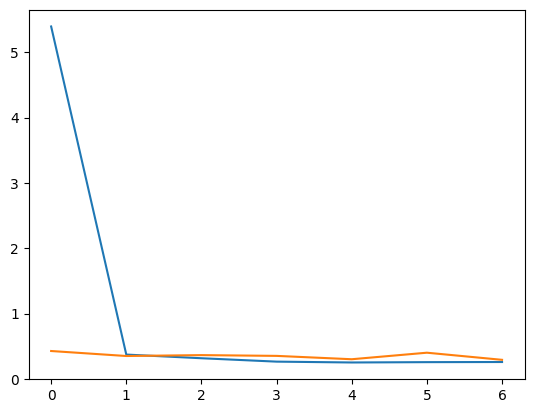

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label = "Training Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")
plt.show()

In [ ]:
waste_cnn_model.evaluate(test_generator)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9375 - loss: 0.3524


[0.3524351716041565, 0.9375]

In [ ]:
waste_cnn_model.save("Waste_Classifier.keras")

In [ ]:
import tensorflow as tf
waste_model = tf.keras.models.load_model("Waste_Classifier.keras")

In [ ]:
#Input the image
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
image_path = "/content/paper.jpg"
my_image = load_img(image_path, target_size = (255, 255))
my_image_array = img_to_array(my_image)
my_image_array = np.expand_dims(my_image_array, axis = 0)
my_image_array = my_image_array/255.0

In [ ]:
prediction = waste_model.predict(my_image_array)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
[[0.90243304]]


In [ ]:
if prediction[0][0] > 0.5:
  label = "Recyclable"
else:
  label = "Organic"
#print(label)

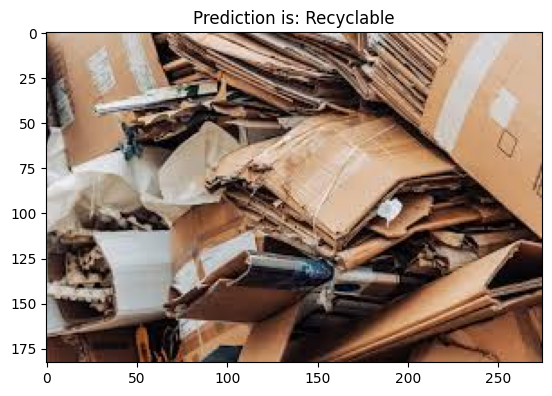

In [ ]:
plt.imshow(load_img(image_path))
plt.title(f"Prediction is: {label}")
plt.show()